# Phase 3 (notebook) — Extraction des sous-motifs (topic modeling)

Remplace `phase3_topics.py`. Objectif : reconstruire ce que le champ
`ticket_attributes_Root cause` aurait du contenir (rempli a 0,02% dans le
fichier source — voir `01_exploration_toutes_colonnes.ipynb`) en decouvrant
les sous-thematiques recurrentes A L'INTERIEUR de chaque categorie deja
connue (`ticket_type_name`), via TF-IDF + NMF sur le texte lemmatise.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, ".")
sys.path.insert(0, "..")

import phase3_topics as p3
from viz_utils import plot_full_counts

PROJECT_DIR = Path("..").resolve()
PHASE2_CSV = PROJECT_DIR / "reclamations_phase2.csv"
PHASE1_CSV = PROJECT_DIR / "reclamations_phase1.csv"
PHASE3_CSV = PROJECT_DIR / "reclamations_phase3.csv"
TOPICS_SUMMARY_CSV = PROJECT_DIR / "topics_summary.csv"

plt.rcParams["figure.dpi"] = 100

df_in = pd.read_csv(PHASE2_CSV if PHASE2_CSV.exists() else PHASE1_CSV, low_memory=False)
print(f"{len(df_in)} tickets charges")

8284 tickets charges


## 1. Volume de texte par categorie

Le topic modeling n'est fiable qu'a partir de 24... (seuil exact :
`phase3_topics.MIN_TICKETS_FOR_TOPICS`). En dessous, une categorie est
neanmoins affichee ici (aucune categorie omise du graphique), mais sera
exclue du topic modeling lui-meme (section 4).

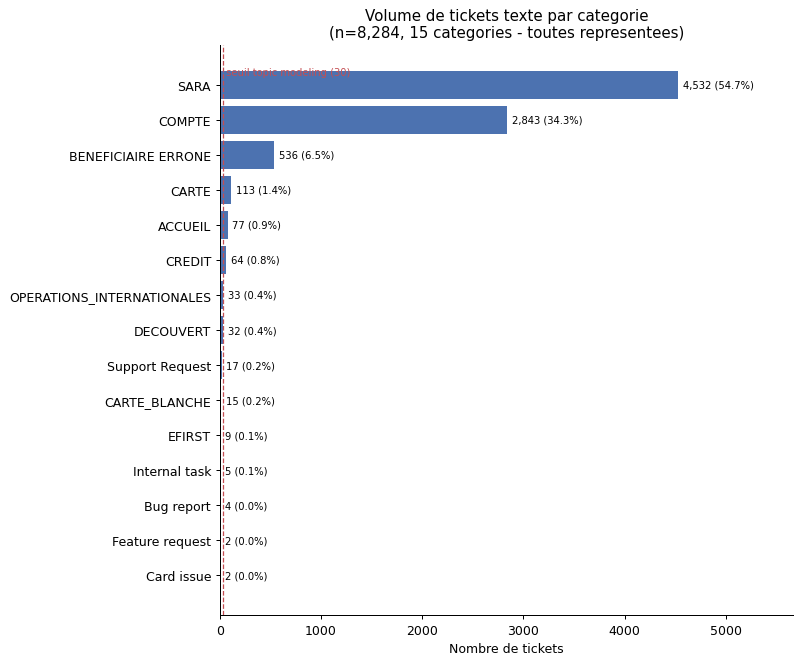

In [2]:
counts_categorie = df_in["ticket_type_name"].value_counts()
fig, ax = plot_full_counts(counts_categorie, "Volume de tickets texte par categorie", xlabel="Nombre de tickets")
ax.axvline(p3.MIN_TICKETS_FOR_TOPICS, color="#C44E52", linestyle="--", linewidth=1)
ax.text(p3.MIN_TICKETS_FOR_TOPICS, len(counts_categorie) - 0.5, f" seuil topic modeling ({p3.MIN_TICKETS_FOR_TOPICS})", color="#C44E52", fontsize=8, va="top")
plt.show()

## 2. Topic modeling (TF-IDF + NMF), categorie par categorie

Meme logique de cache que les notebooks precedents : si `reclamations_phase3.csv`
et `topics_summary.csv` existent deja, on les charge ; sinon on relance le
NMF categorie par categorie (identique a `phase3_topics.py`).

In [3]:
if PHASE3_CSV.exists() and TOPICS_SUMMARY_CSV.exists():
    print("Cache trouve -> chargement de reclamations_phase3.csv et topics_summary.csv.")
    df3 = pd.read_csv(PHASE3_CSV, low_memory=False)
    summary_df = pd.read_csv(TOPICS_SUMMARY_CSV)
else:
    print("Pas de cache : topic modeling NMF categorie par categorie...")
    df3 = df_in.copy()
    df3["topic_id"] = -1
    df3["topic_keywords"] = ""
    summary_rows = []
    skipped = []

    for category, n_tickets in counts_categorie.items():
        mask = df3["ticket_type_name"] == category
        topic_ids, keywords = p3.topic_model_category(df3.loc[mask, "texte_lemmatise"])
        if not keywords:
            skipped.append((category, n_tickets))
            continue
        df3.loc[mask, "topic_id"] = topic_ids
        df3.loc[mask, "topic_keywords"] = topic_ids.map(lambda t: keywords[t] if t >= 0 else "")
        for t, kw in enumerate(keywords):
            count = int((topic_ids == t).sum())
            summary_rows.append({"categorie": category, "topic_id": t, "nb_tickets": count, "mots_cles": kw})

    summary_df = pd.DataFrame(summary_rows).sort_values(["categorie", "nb_tickets"], ascending=[True, False])
    df3.to_csv(PHASE3_CSV, index=False)
    summary_df.to_csv(TOPICS_SUMMARY_CSV, index=False)
    print(f"Ecrit : {PHASE3_CSV.name}, {TOPICS_SUMMARY_CSV.name}")
    print(f"Categories exclues (trop peu de texte) : {skipped}")

print(f"{len(summary_df)} topics decouverts sur {summary_df['categorie'].nunique()} categories.")

Cache trouve -> chargement de reclamations_phase3.csv et topics_summary.csv.
34 topics decouverts sur 8 categories.


## 3. Categories exclues du topic modeling — transparence

Une categorie sans texte suffisant n'est pas retiree du graphique de la
section 1, mais elle n'a pas de sous-motifs NMF. Liste explicite ci-dessous
(plutot que de la laisser disparaitre silencieusement).

In [4]:
categories_avec_topics = set(summary_df["categorie"].unique())
categories_toutes = set(counts_categorie.index)
categories_exclues = categories_toutes - categories_avec_topics

print(f"{len(categories_avec_topics)}/{len(categories_toutes)} categories ont assez de texte pour le topic modeling.")
print("Categories exclues (moins de "
      f"{p3.MIN_TICKETS_FOR_TOPICS} tickets avec texte) :")
for c in sorted(categories_exclues):
    print(f"  - {c} ({counts_categorie.get(c, 0)} tickets)")

8/15 categories ont assez de texte pour le topic modeling.
Categories exclues (moins de 30 tickets avec texte) :
  - Bug report (4 tickets)
  - CARTE_BLANCHE (15 tickets)
  - Card issue (2 tickets)
  - EFIRST (9 tickets)
  - Feature request (2 tickets)
  - Internal task (5 tickets)
  - Support Request (17 tickets)


## 4. Tous les topics decouverts — volume complet (pas de top 10)

L'ancien rapport ne montrait que les 10 sous-motifs les plus "critiques"
(volume x %negatif). Ici, les 34 topics sont tous representes par volume ;
le croisement avec le sentiment est fait dans `05_reporting.ipynb`.

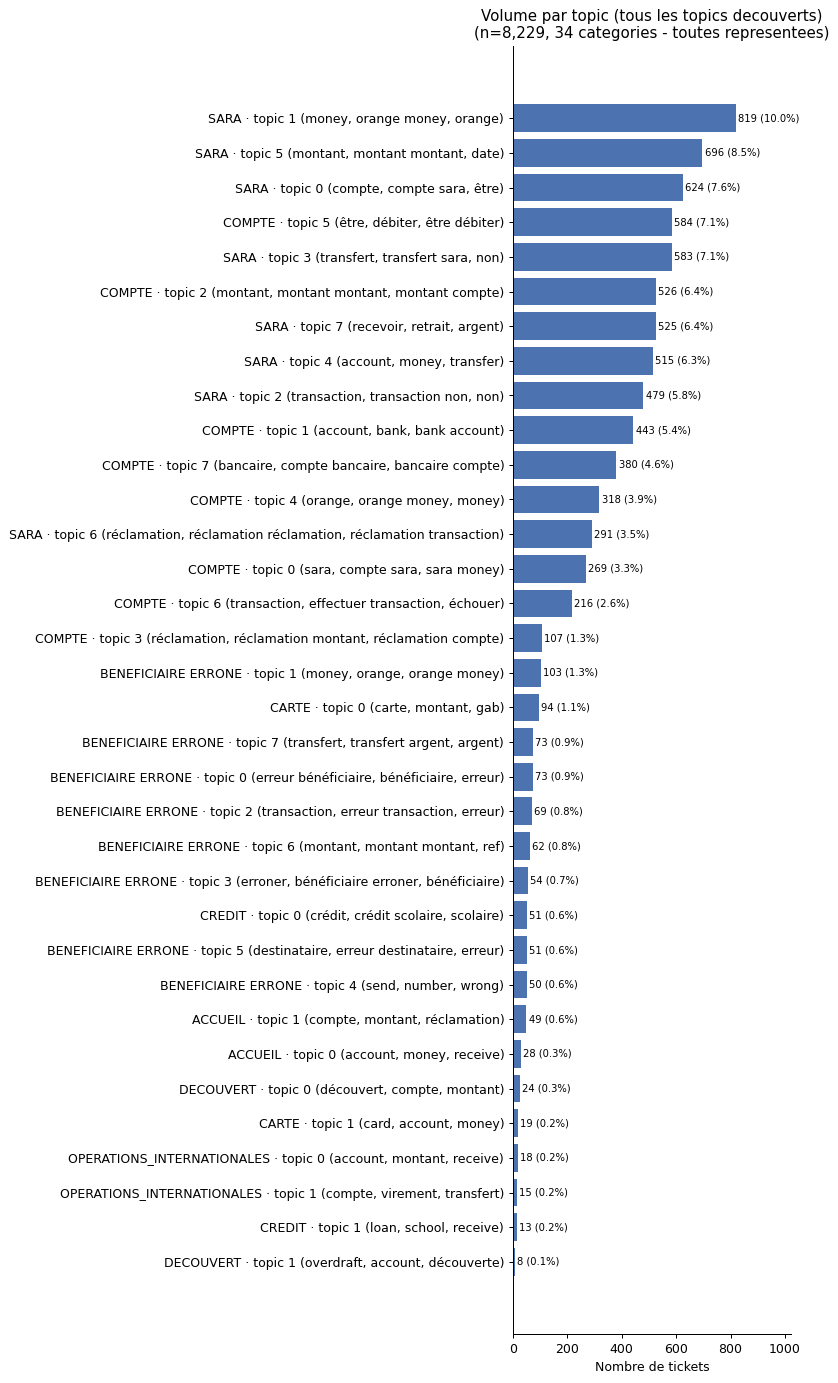

In [5]:
summary_df["label"] = (
    summary_df["categorie"] + " · topic " + summary_df["topic_id"].astype(str)
    + " (" + summary_df["mots_cles"].str.split(", ").str[:3].str.join(", ") + ")"
)
volumes = summary_df.set_index("label")["nb_tickets"]
fig, ax = plot_full_counts(volumes, "Volume par topic (tous les topics decouverts)", xlabel="Nombre de tickets")
plt.show()